# Similarity and Distance

This tutorial illustrates how to calculate similarity and distance between images.

## Load Data
 
First, let's load the pain data for this example.

In [ ]:
from nltools.datasets import fetch_pain

data = fetch_pain()

## Distance

We can calculate the pairwise spatial distance between all images in a BrainData()
instance using any method from sklearn or scipy.  This outputs an Adjacency() class
object.

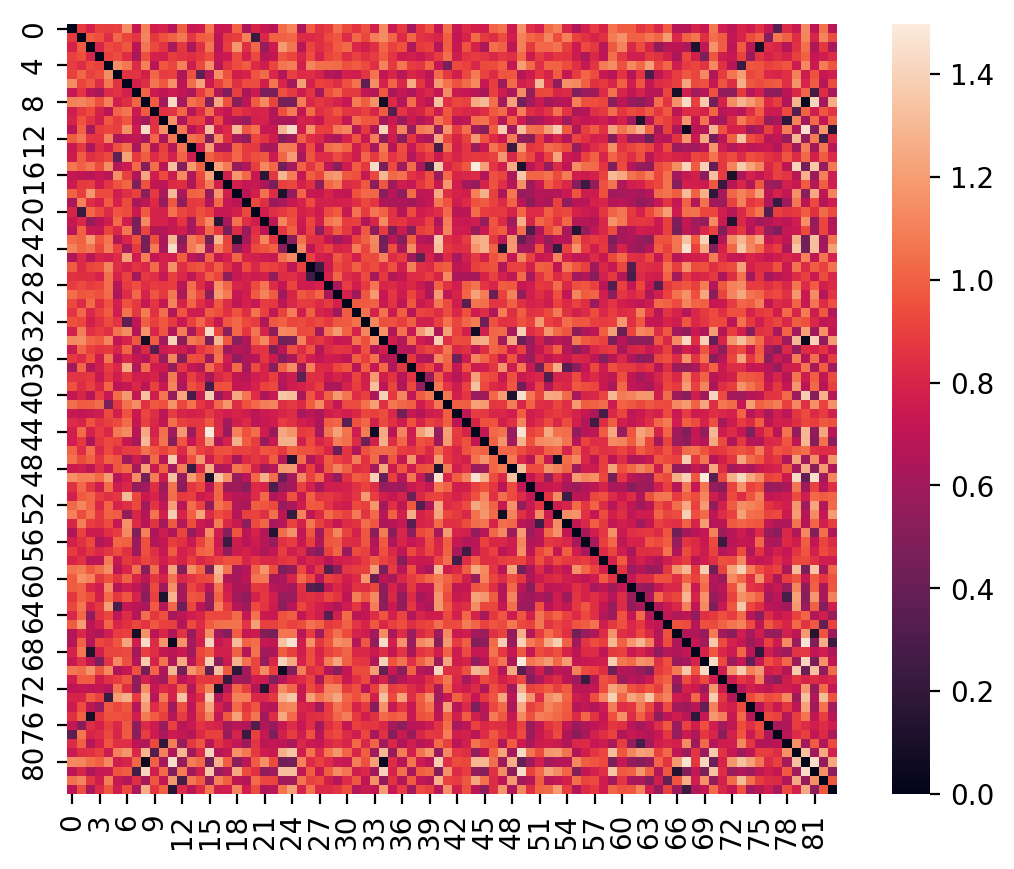

In [2]:
d = data.distance(metric="correlation")
d.plot()

## Similarity
 
The similarity of an image to other images can be computed using the similarity()
method.  Here we calculate the mean image for high pain intensity across all participants
and calculate the degree of spatial similarity between this image and all pain intensities
for all participants.  This is a useful method for calculating pattern responses.

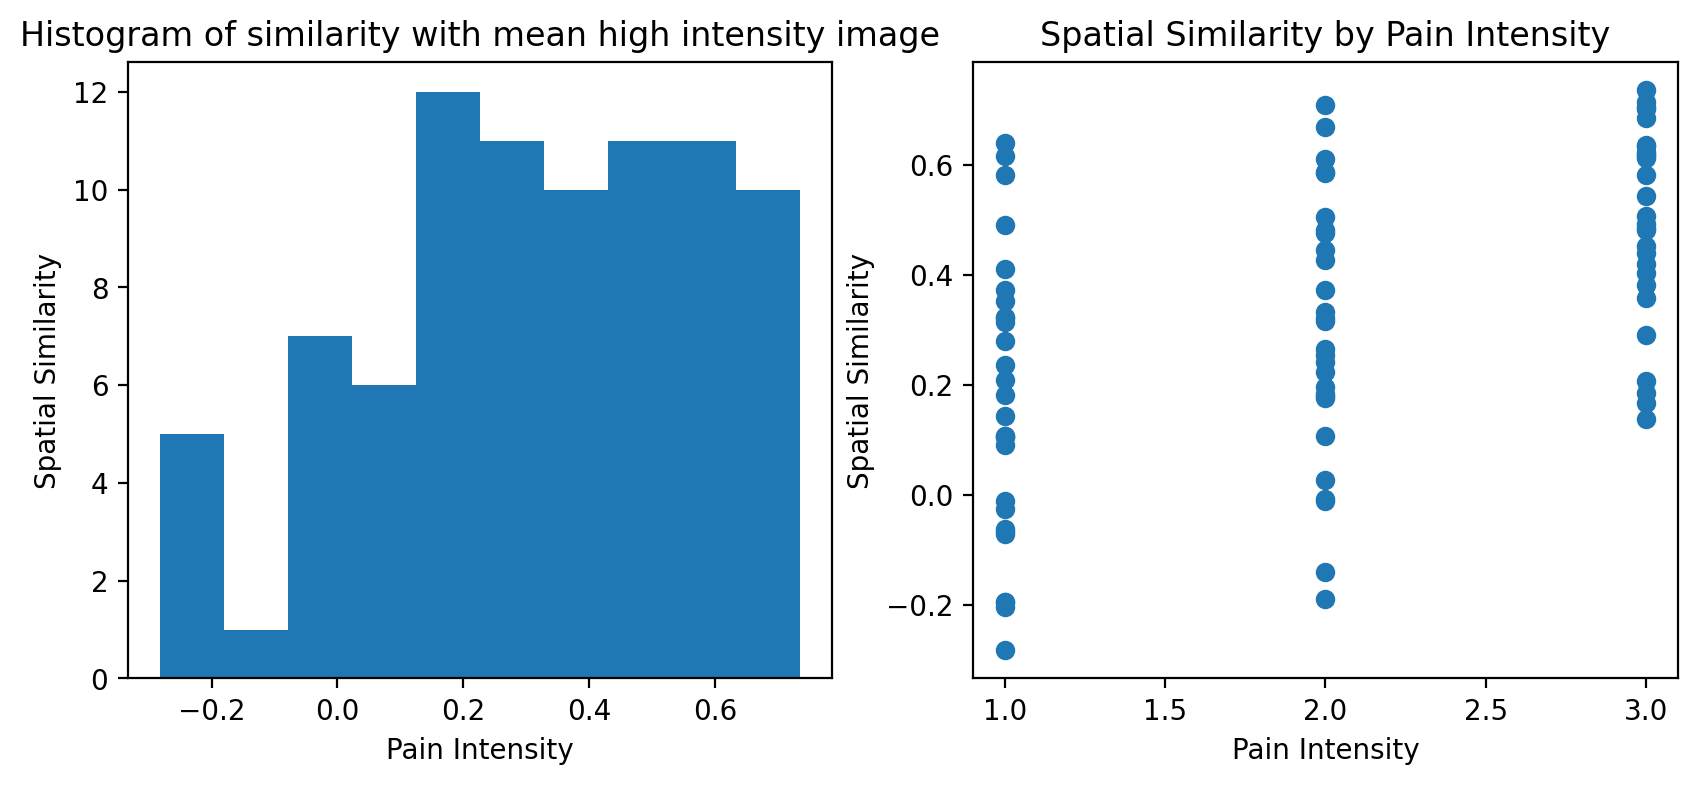

In [4]:
import numpy as np
import matplotlib.pylab as plt

high = data[np.where(data.X["PainLevel"] == 3)[0]].mean()
r = high.similarity(data, method="correlation")

f, a = plt.subplots(ncols=2, figsize=(10, 4))
a[0].hist(r)
a[0].set_ylabel("Spatial Similarity")
a[0].set_xlabel("Pain Intensity")
a[0].set_title("Histogram of similarity with mean high intensity image")
a[1].scatter(data.X["PainLevel"], r)
a[1].set_ylabel("Spatial Similarity")
a[1].set_xlabel("Pain Intensity")
a[1].set_title("Spatial Similarity by Pain Intensity");